In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import ImageFolder
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models # <-- ADDED for ResNet
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np
import random
import os
import copy
import sys

# from tqdm import tqdm # <-- REMOVED to debug freezing issue

# Magic command for Jupyter to display plots inline
%matplotlib inline

In [29]:
from google.colab import drive
import zipfile

In [30]:
print("Mounting Google Drive...")
drive.mount('/content/drive')

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
ZIP_FILE_PATH = '/content/drive/MyDrive/data.zip'

In [32]:
EXTRACT_DIR = '/content/data'

In [33]:
if not os.path.exists(EXTRACT_DIR):
    print(f"Extracting '{ZIP_FILE_PATH}' to '{EXTRACT_DIR}'...")
    try:
        with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
            zip_ref.extractall(EXTRACT_DIR)
        print("Extraction complete.")
    except FileNotFoundError:
        print(f"ERROR: Zip file not found at '{ZIP_FILE_PATH}'")
        print("Please update the ZIP_FILE_PATH variable.")
    except Exception as e:
        print(f"An error occurred during extraction: {e}")
else:
    print(f"Data already extracted at '{EXTRACT_DIR}'.")

# 4. Define the TRAIN and TEST data paths based on the extracted folder
# Assumes the zip file extracts to a folder named 'NWPU-RESISC45'
# which contains 'train' and 'test' subfolders.




Data already extracted at '/content/data'.


In [34]:
BASE_DATA_PATH = os.path.join(EXTRACT_DIR, 'data', 'NWPU-RESISC45')
TRAIN_DATA_PATH = os.path.join(BASE_DATA_PATH, 'train')
TEST_DATA_PATH = os.path.join(BASE_DATA_PATH, 'test')

print(f"TRAIN_DATA_PATH set to: {TRAIN_DATA_PATH}")
print(f"TEST_DATA_PATH set to: {TEST_DATA_PATH}")

TRAIN_DATA_PATH set to: /content/data/data/NWPU-RESISC45/train
TEST_DATA_PATH set to: /content/data/data/NWPU-RESISC45/test


In [35]:
NUM_CLIENTS = 10        # Number of clients to simulate
NUM_ROUNDS = 20         # Number of communication rounds
LOCAL_EPOCHS = 3        # Number of local training epochs on each client
BATCH_SIZE = 8          # <-- Kept at 8 for memory safety
LEARNING_RATE = 0.001
CLIENT_TEST_SPLIT = 0.2 # Each client holds out 20% of its data for local testing
NUM_CLASSES = 45

In [36]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {DEVICE}")

Running on device: cuda


In [37]:
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [38]:
def create_resnet_model(num_classes=NUM_CLASSES):
    """
    Loads a pre-trained ResNet18 model and replaces the final
    fully connected layer for transfer learning.

    Includes a fallback for older torchvision versions.
    """

    try:
        # --- New way (torchvision >= 0.13) ---
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET_V1)
        print("Loaded ResNet18 with `weights=...` (new method).")
    except AttributeError:
        # --- Old way (torchvision < 0.13) ---
        print("`IMAGENET_V1` weights not found. Falling back to `pretrained=True` (old method).")
        print("This is common with older torchvision versions.")
        model = models.resnet18(pretrained=True)

    # Freeze all the parameters in the pre-trained model
    for param in model.parameters():
        param.requires_grad = False

    # Get the number of input features for the final layer
    num_ftrs = model.fc.in_features

    # Replace the final layer with a new, unfrozen layer for our 45 classes
    # This new layer *will* be trained
    model.fc = nn.Linear(num_ftrs, num_classes)

    print(f"Loaded pre-trained ResNet18 model. Replaced FC layer for {num_classes} classes.")

    return model

In [39]:
import torchvision.transforms as transforms # <-- ADDED THIS LINE to fix NameError

def get_dataloaders(train_path, test_path, num_clients):
    """
    Loads the NWPU-RESISC45 dataset from pre-split 'train' and 'test' folders
    and partitions the training data among clients in an IID fashion.
    """
    if not os.path.exists(train_path):
        print(f"Error: Training data path not found at '{train_path}'")
        print("Please check your `TRAIN_DATA_PATH` variable.")
        print("See README.md for instructions.")
        raise FileNotFoundError(f"Training path not found: {train_path}")
    if not os.path.exists(test_path):
        print(f"Error: Test data path not found at '{test_path}'")
        print("Please check your `TEST_DATA_PATH` variable.")
        print("See README.md for instructions.")
        raise FileNotFoundError(f"Test path not found: {test_path}")

    # <-- UPDATED: Transforms for ResNet (224x224 and ImageNet normalization) -->
    transform = transforms.Compose([
        transforms.Resize((224, 224)), # ResNet expects 224x224
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet stats
    ])

    # Load the entire TRAINING dataset
    train_dataset = ImageFolder(root=train_path, transform=transform)

    # Load the entire TEST dataset
    global_test_dataset = ImageFolder(root=test_path, transform=transform)
    # --- REVERTED to num_workers=0 to fix deadlocks ---
    global_test_loader = DataLoader(
        global_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
    )

    # The entire training dataset is now the client pool
    pool_size = len(train_dataset)
    client_pool_indices = list(range(pool_size))
    np.random.shuffle(client_pool_indices)

    # Partition client pool indices among clients (IID)
    client_indices = np.array_split(client_pool_indices, num_clients)

    client_loaders = [] # List of (train_loader, test_loader)
    client_data_sizes = [] # List of train data sizes for FedAvg

    for i in range(num_clients):
        client_idx = client_indices[i]

        # Split this client's data into their local train and local test
        local_test_size = int(len(client_idx) * CLIENT_TEST_SPLIT)
        local_train_size = len(client_idx) - local_test_size

        # Ensure indices are shuffled before splitting
        np.random.shuffle(client_idx)

        local_train_idx = client_idx[:local_train_size]
        local_test_idx = client_idx[local_train_size:]

        # Create subsets from the training dataset
        local_train_dataset = Subset(train_dataset, local_train_idx)
        local_test_dataset = Subset(train_dataset, local_test_idx)

        # Create dataloaders
        # --- REVERTED to num_workers=0 to fix deadlocks ---
        train_loader = DataLoader(
            local_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0
        )
        test_loader = DataLoader(
            local_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0
        )

        client_loaders.append((train_loader, test_loader))
        client_data_sizes.append(local_train_size)

    print(f"Data loaded: {pool_size} TRAIN samples for {num_clients} clients, {len(global_test_dataset)} for global test.")
    return global_test_loader, client_loaders, client_data_sizes


In [40]:
def imshow(tensor_img, title=None):
    """Imshow for Tensor."""
    # <-- UPDATED: De-normalize using ImageNet stats -->
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = tensor_img.clone().cpu() * std + mean
    img = img.numpy().transpose((1, 2, 0)) # C H W -> H W C
    img = np.clip(img, 0, 1) # Ensure values are in [0, 1] range

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis('off')
    plt.show()

Attempting to load data for verification...
Data loaded: 27000 TRAIN samples for 1 clients, 4500 for global test.
Found 45 classes.

--- Data Check Passed ---
Images batch shape: torch.Size([8, 3, 224, 224])
Labels batch shape: torch.Size([8])


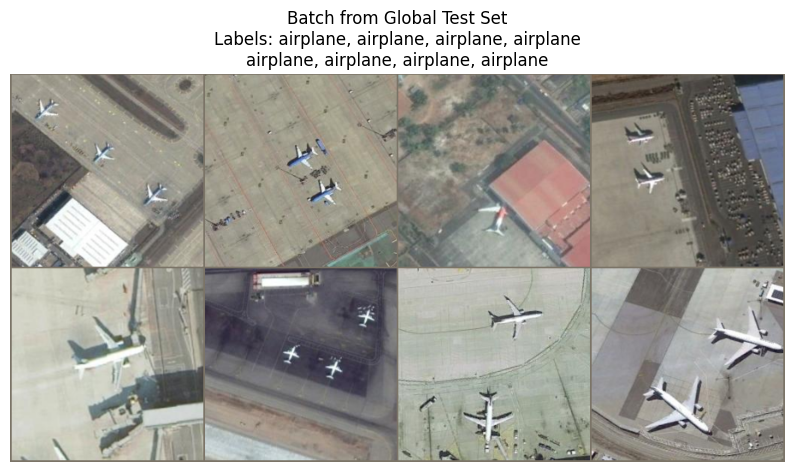

In [41]:
try:
    print("Attempting to load data for verification...")
    # We only need the global test loader for this check
    # --- This function call now implicitly uses num_workers=0 ---
    verify_global_loader, _, _ = get_dataloaders(
        TRAIN_DATA_PATH, TEST_DATA_PATH, num_clients=1
    )

    # Get the class names from the dataset object
    class_names = verify_global_loader.dataset.classes
    print(f"Found {len(class_names)} classes.")

    # Get one batch of test images
    dataiter = iter(verify_global_loader)
    images, labels = next(dataiter)

    print("\n--- Data Check Passed ---")
    print(f"Images batch shape: {images.shape}") # Should be [B, 3, 224, 224]
    print(f"Labels batch shape: {labels.shape}")

    # Show first 8 images from the batch
    # Use the full path to avoid alias issues
    img_grid = torchvision.utils.make_grid(images[:8], nrow=4)

    # Get corresponding labels
    label_names = [class_names[labels[j]] for j in range(8)]
    title = "Batch from Global Test Set\nLabels: " + ", ".join(label_names[:4]) + "\n" + ", ".join(label_names[4:])

    imshow(img_grid, title=title)

except FileNotFoundError as e:
    print(f"\n--- Data Check Failed ---")
    print(f"Error: {e}")
    print("Please double-check your TRAIN_DATA_PATH and TEST_DATA_PATH variables in Cell 2.")
except Exception as e:
    print(f"\n--- Data Check Failed ---")
    print(f"An unexpected error occurred: {e}")
    print("Your dataset might be corrupted or not in the expected ImageFolder format.")



In [42]:
import torch.optim as optim # <-- ADDED THIS LINE to fix NameError

class Client:
    """
    Simulates a single client device.
    """
    def __init__(self, client_id, model_template, train_loader, test_loader, device):
        self.client_id = client_id
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.device = device

        # Each client gets a *copy* of the model architecture
        self.model = copy.deepcopy(model_template).to(device)

        # --- UPDATED: Optimizer should only train the *new* FC layer ---
        # We find the parameters that were not frozen (i.e., requires_grad=True)
        params_to_train = filter(lambda p: p.requires_grad, self.model.parameters())
        self.optimizer = optim.Adam(params_to_train, lr=LEARNING_RATE)
        # ---

        self.criterion = nn.CrossEntropyLoss()

        # Per-client metric for LOCAL TEST data
        self.acc_metric = torchmetrics.classification.MulticlassAccuracy(
            num_classes=NUM_CLASSES
        ).to(device)

        # Per-client metric for LOCAL TRAIN data (for epoch logging)
        self.train_acc_metric = torchmetrics.classification.MulticlassAccuracy(
            num_classes=NUM_CLASSES
        ).to(device)

    def set_parameters(self, global_state_dict):
        """Load global model weights."""
        self.model.load_state_dict(global_state_dict)

    def train(self, local_epochs):
        """Train the model on local data."""
        self.model.train()
        print(f"  > Client {self.client_id}: Starting local training...")

        for epoch in range(local_epochs):

            # --- Reset metrics for the epoch ---
            self.train_acc_metric.reset()
            total_epoch_loss = 0.0
            num_batches = 0

            # --- START: Simplified loop (no per-batch logging) ---
            try:
                for batch_idx, (images, labels) in enumerate(self.train_loader):
                    images, labels = images.to(self.device), labels.to(self.device)

                    self.optimizer.zero_grad()
                    outputs = self.model(images)
                    loss = self.criterion(outputs, labels)
                    loss.backward()
                    self.optimizer.step()

                    # --- Update epoch metrics ---
                    total_epoch_loss += loss.item()
                    self.train_acc_metric.update(outputs, labels)
                    num_batches += 1

            except Exception as e:
                # This will catch corrupted data OR potential OOM errors during a batch
                print(f"    ! Client {self.client_id} Error: Failed to process a batch. Skipping. Error: {e}")
                pass # Continue to the next epoch
            # --- END: Simplified loop ---

            # --- Print epoch-level stats (MOVED) ---
            # This block is no longer inside the epoch loop

        # --- Print FINAL epoch-level stats ---
        # (This block is now OUTSIDE the epoch loop, will run once)
        if num_batches > 0:
            avg_epoch_loss = total_epoch_loss / num_batches
            epoch_train_acc = self.train_acc_metric.compute().item()
            print(f"    > Client {self.client_id} Final Epoch Summary: Avg Loss: {avg_epoch_loss:.4f}, Train Acc: {epoch_train_acc:.4f}")
        else:
            print(f"    > Client {self.client_id} Final Epoch Summary: No batches processed successfully.")

        print(f"  > Client {self.client_id}: Local training complete.")

    def get_parameters(self):
        """Return local model weights."""
        return self.model.state_dict()

    def evaluate(self):
        """Evaluate the model on the local test set."""
        self.model.eval()
        self.acc_metric.reset()

        with torch.no_grad():
            for images, labels in self.test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                outputs = self.model(images)
                self.acc_metric.update(outputs, labels)

        accuracy = self.acc_metric.compute().item()
        return accuracy


In [43]:
def fed_avg(client_weights_list, client_data_sizes):
    """
    Performs the Federated Averaging (FedAvg) aggregation.
    This function can be replaced with other aggregation schemes.

    Args:
        client_weights_list (list): A list of model state_dicts from clients.
        client_data_sizes (list): A list of training data sizes (int) for each client.

    Returns:
        dict: The aggregated (averaged) state_dict for the global model.
    """
    # Calculate weights
    total_data_size = sum(client_data_sizes)
    weights = [size / total_data_size for size in client_data_sizes]

    # Initialize a new state_dict for the averaged model
    avg_state_dict = copy.deepcopy(client_weights_list[0])

    # Zero out all parameters
    for key in avg_state_dict.keys():
        avg_state_dict[key] = torch.zeros_like(avg_state_dict[key])

    # Perform weighted average
    for key in avg_state_dict.keys():
        for i, state_dict in enumerate(client_weights_list):
            avg_state_dot = state_dict.get(key)
            if avg_state_dot is not None:
                # --- IMPORTANT: Only average the layers that were trained ---
                # (In our case, this is just the 'fc' layer)
                if avg_state_dict[key].requires_grad:
                    avg_state_dict[key] += avg_state_dot * weights[i]
                else:
                    # For frozen layers, just copy from the first client (they are all the same)
                    if i == 0:
                         avg_state_dict[key] = avg_state_dot

    return avg_state_dict

In [44]:
def evaluate_global(model, test_loader, device, metrics_dict):
    """
    Evaluates the global model on the hold-out global test set.

    Args:
        model (nn.Module): The global model to evaluate.
        test_loader (DataLoader): The global test data loader.
        device (torch.device): The device to run on.
        metrics_dict (dict): A dict of torchmetrics, e.g., {'acc': acc_metric, 'f1': f1_metric}

    Returns:
        dict: A dict of computed metric values, e.g., {'acc': 0.95, 'f1': 0.92}
    """
    model.eval()

    # Reset all metrics
    for metric in metrics_dict.values():
        metric.reset()

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            # Update metrics
            metrics_dict['acc'].update(outputs, labels)
            metrics_dict['f1'].update(outputs, labels)

            # AUROC needs probabilities
            probs = F.softmax(outputs, dim=1)
            metrics_dict['auc'].update(probs, labels)

    # Compute final results
    results = {
        'acc': metrics_dict['acc'].compute().item(),
        'f1': metrics_dict['f1'].compute().item(),
        'auc': metrics_dict['auc'].compute().item(),
    }
    return results

In [45]:
def get_model_bytes(model, only_trainable=False):
    """
    Calculates the total size of a model's parameters in bytes.
    If only_trainable=True, only counts the non-frozen parameters.
    """
    total_bytes = 0
    for param in model.parameters():
        if only_trainable and not param.requires_grad:
            continue
        total_bytes += param.numel() * param.element_size()
    return total_bytes

In [ ]:
def main():
    print(f"--- Federated Learning Simulation ---")
    # Device was already printed in the config cell
    print(f"Simulating {NUM_CLIENTS} clients for {NUM_ROUNDS} rounds...")

    # 1. Load and partition data
    try:
        global_test_loader, client_loaders, client_data_sizes = get_dataloaders(
            TRAIN_DATA_PATH, TEST_DATA_PATH, NUM_CLIENTS
        )
    except Exception as e:
        print(f"Failed to load data: {e}")
        print("Please ensure your paths are correct and you have run the data setup from README.md")
        return

    # 2. Initialize models and clients
    # <-- UPDATED: Use ResNet model template -->
    model_template = create_resnet_model(num_classes=NUM_CLASSES) # CPU template
    global_model = copy.deepcopy(model_template).to(DEVICE)

    clients = []
    for i in range(NUM_CLIENTS):
        train_loader, test_loader = client_loaders[i]
        client = Client(
            client_id=i,
            model_template=model_template,
            train_loader=train_loader,
            test_loader=test_loader,
            device=DEVICE
        )
        clients.append(client)

    # 3. Initialize global metrics
    global_metrics_dict = {
        'acc': torchmetrics.classification.MulticlassAccuracy(
            num_classes=NUM_CLASSES
        ).to(DEVICE),
        'f1': torchmetrics.classification.MulticlassF1Score(
            num_classes=NUM_CLASSES, average='macro'
        ).to(DEVICE),
        'auc': torchmetrics.classification.MulticlassAUROC(
            num_classes=NUM_CLASSES, average='macro', thresholds=None
        ).to(DEVICE)
    }

    # 4. Initialize logs
    global_acc_log = []
    global_f1_log = []
    global_auc_log = []
    cumulative_comm_log = []
    comm_log = {}

    # --- UPDATED: Calculate communication cost ---
    # With transfer learning, we have two options:
    # 1. Send the *entire* model (simpler, more realistic)
    # 2. Send *only* the trained layer (more efficient, but more complex)
    # We will simulate option 1 for simplicity, but calculate both.

    # Option 1: Entire model is sent
    bytes_per_client_down = get_model_bytes(global_model, only_trainable=False) # Server to Client
    # Option 2: Clients only send back the *trained* part
    bytes_per_client_up = get_model_bytes(global_model, only_trainable=True)   # Client to Server

    print("\n--- Model Size & Communication ---")
    print(f"Full model size (Server -> Client): {bytes_per_client_down / (1024**2):.2f} MB")
    print(f"Trainable params size (Client -> Server): {bytes_per_client_up / (1024**2):.2f} MB")

    # 5. Start Federated Training Loop
    print("\n--- Starting Simulation ---")

    total_comm_bytes = 0

    for round_num in range(NUM_ROUNDS):
        print(f"\n--- Round {round_num + 1}/{NUM_ROUNDS} ---")

        # Get current global model weights
        global_state_dict = global_model.state_dict()

        client_weights_list = []
        current_client_data_sizes = [] # Data sizes of clients in this round

        # --- Client Phase ---
        # In a real simulation, you'd select a subset of clients
        # Here we simulate all clients participating
        for client in clients:
            # 1. Send model to client
            client.set_parameters(global_state_dict)
            total_comm_bytes += bytes_per_client_down # Log bytes sent

            # 2. Client trains
            client.train(LOCAL_EPOCHS)

            # 3. Get model from client
            client_weights_list.append(client.get_parameters())
            current_client_data_sizes.append(len(client.train_loader.dataset))
            total_comm_bytes += bytes_per_client_up # Log bytes received

        # Log communication for this round
        bytes_this_round = (bytes_per_client_down + bytes_per_client_up) * NUM_CLIENTS
        comm_log[f"Round {round_num+1}"] = {
            "bytes_sent": bytes_per_client_down * NUM_CLIENTS,
            "bytes_received": bytes_per_client_up * NUM_CLIENTS,
            "total_bytes_this_round": bytes_this_round
        }
        cumulative_comm_log.append(total_comm_bytes)

        # --- Server Phase ---
        print(f"...Server aggregating {len(client_weights_list)} client models...")
        # 4. Aggregate models (FedAvg)
        global_state_dict = fed_avg(client_weights_list, current_client_data_sizes)
        global_model.load_state_dict(global_state_dict)

        # 5. Evaluate new global model
        print(f"...Server evaluating new global model on {len(global_test_loader.dataset)} test images (can take a minute)...")
        metrics = evaluate_global(global_model, global_test_loader, DEVICE, global_metrics_dict)

        global_acc_log.append(metrics['acc'])
        global_f1_log.append(metrics['f1'])
        global_auc_log.append(metrics['auc'])

        print(f"Round {round_num + 1} Global Metrics: "
              f"Acc: {metrics['acc']:.4f}, "
              f"F1: {metrics['f1']:.4f}, "
              f"AUC: {metrics['auc']:.4f}")

    # 6. Simulation Finished - Print Final Report
    print("\n--- Simulation Finished ---")

    # --- Per-client performance
    print("\n--- Final Per-Client Performance (on local test sets) ---")
    client_final_acc = []
    for i, client in enumerate(clients):
        local_acc = client.evaluate()
        client_final_acc.append(local_acc)
        print(f"  Client {i:2}: Final Local Test Accuracy: {local_acc:.4f}")

    acc_variance = np.var(client_final_acc)
    print(f"  > Variance in client accuracy: {acc_variance:.4f}")

    # --- Communication Report ---
    print("\n--- Communication Report ---")
    mb_sent_per_round = (bytes_per_client_down * NUM_CLIENTS) / (1024**2)
    mb_recd_per_round = (bytes_per_client_up * NUM_CLIENTS) / (1024**2)
    print(f"  MB SENT per round: {mb_sent_per_round:.2f} MB")
    print(f"  MB RECEIVED per round: {mb_recd_per_round:.2f} MB")
    total_gb = total_comm_bytes / (1024**3)
    print(f"  Total Communication: {total_gb:.2f} GB")


    # --- Generate Analysis Graphs ---
    print("\n--- Generating Analysis Graphs ---")
    rounds_axis = range(1, NUM_ROUNDS + 1)

    # --- Plot 1: Combined Global Metrics ---
    plt.figure(figsize=(10, 6))
    plt.plot(rounds_axis, global_acc_log, marker='o', label='Accuracy')
    plt.plot(rounds_axis, global_f1_log, marker='s', label='F1 Score (Macro)')
    plt.plot(rounds_axis, global_auc_log, marker='^', label='AUC (Macro)')
    plt.title('Global Model Performance vs. Communication Rounds')
    plt.xlabel('Communication Round')
    plt.ylabel('Metric Value')
    plt.legend()
    plt.grid(True)
    plt.xticks(rounds_axis[::max(1, len(rounds_axis)//10)]) # Show ticks every 10%
    plt.show()

    # --- Plot 2: Final Per-Client Accuracy Variance ---
    client_ids = [f'Client {i}' for i in range(NUM_CLIENTS)]
    plt.figure(figsize=(12, 6))
    plt.bar(client_ids, client_final_acc, color='skyblue')
    plt.title('Final Per-Client Accuracy (on Local Test Data)')
    plt.xlabel('Client ID')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.0)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    for i, acc in enumerate(client_final_acc):
        plt.text(i, acc + 0.01, f'{acc:.3f}', ha='center', color='black')
    plt.show()

    # --- Plot 3: Cumulative Communication Cost ---
    cumulative_comm_gb = [b / (1024**3) for b in cumulative_comm_log]
    plt.figure(figsize=(10, 6))
    plt.plot(rounds_axis, cumulative_comm_gb, marker='o', color='green', label='Total Communication')
    plt.title('Cumulative Communication Cost vs. Rounds')
    plt.xlabel('Communication Round')
    plt.ylabel('Total Communication (GB)')
    plt.legend()
    plt.grid(True)
    plt.xticks(rounds_axis[::max(1, len(rounds_axis)//10)])
    plt.show()

# This block ensures the main() function runs when you execute the cell
if __name__ == "__main__" or "ipykernel" in " ".join(sys.argv):
    main()

--- Federated Learning Simulation ---
Simulating 10 clients for 20 rounds...
Data loaded: 27000 TRAIN samples for 10 clients, 4500 for global test.
`IMAGENET_V1` weights not found. Falling back to `pretrained=True` (old method).
This is common with older torchvision versions.


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


Loaded pre-trained ResNet18 model. Replaced FC layer for 45 classes.

--- Model Size & Communication ---
Full model size (Server -> Client): 42.72 MB
Trainable params size (Client -> Server): 0.09 MB

--- Starting Simulation ---

--- Round 1/20 ---
  > Client 0: Starting local training...
    > Client 0 Final Epoch Summary: Avg Loss: 1.3864, Train Acc: 0.6466
  > Client 0: Local training complete.
  > Client 1: Starting local training...
